# Solar heating due to shortwave forcing anomalies decomposed into that falling on sea ice versus open ocean LENS1

By Ali Siddiqui

August 2025

- LENS1 instead of LENS2
- Using albedo computed from radiative fluxes instead of the diagnostic output

In [1]:
import os
os.environ['PROJ_LIB'] = '/glade/u/home/asiddiqui/miniconda3/share/proj'

In [2]:
# remove temp dask worker files
!rm -f dask*

In [3]:
%load_ext watermark

import cf_xarray as cfxr
import dask_jobqueue
import distributed
import intake
import intake_esm
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pint_xarray
from matplotlib.ticker import FormatStrFormatter
import xarray as xr
from cf_xarray.units import units
from matplotlib.patches import FancyBboxPatch# loads some UDUNITS definitions
import xeofs
import pop_tools
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


import xarray as xr
import seaborn as sns
from matplotlib.gridspec import GridSpec
from cartopy.crs import Robinson, PlateCarree

from xeofs.models import MCA, MCARotator

import cmocean
from matplotlib.patches import Polygon
%matplotlib inline

import warnings

import matplotlib.path                 as mpath
import cartopy.crs                     as ccrs
import cartopy.mpl.ticker              as ctk
import cartopy.feature as cfeature
import cartopy.mpl.patch as cpatch
import matplotlib as mpl

import shapely
import geopandas as gpd
import salem
import regionmask
from matplotlib.ticker import AutoMinorLocator

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


import intake
import matplotlib.pyplot as plt
import xarray as xr
from distributed import Client
from ncar_jobqueue import NCARCluster
import itertools


import cartopy.feature as cfeature
land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor='face',
                                        facecolor=cfeature.COLORS['land'])

xr.set_options(keep_attrs=True)

%watermark -iv

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_55906/2908449532.py:46: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


intake       : 0.7.0
seaborn      : 0.12.2
sys          : 3.10.12 | packaged by conda-forge | (main, Jun 23 2023, 22:40:32) [GCC 12.3.0]
intake_esm   : 2023.6.14
numpy        : 1.23.5
distributed  : 2023.6.0
cartopy      : 0.21.1
xeofs        : 1.0.3
matplotlib   : 3.7.1
salem        : 0.3.10
cf_xarray    : 0.8.2
geopandas    : 0.13.2
pint_xarray  : 0.3
regionmask   : 0.12.1
dask_jobqueue: 0.8.2
cmocean      : 3.0.3
xarray       : 2023.6.0
shapely      : 2.0.1
pop_tools    : 2023.3.0



In [4]:
import matplotlib.pylab as pylab

pylab.rcParams.update({
  "text.usetex": False
})
plt.rcParams['font.family'] = 'Sans Serif'
plt.rcParams['font.serif'] = ['Helvetica']

In [5]:
cluster = dask_jobqueue.PBSCluster(
    cores=1,  # The number of cores you want
    memory='50GB',  # Amount of memory
    processes=1,  # How many processes
    queue='casper',  # The type of queue to utilize (/glade/u/apps/dav/opt/usr/bin/execcasper)
    local_directory='$TMPDIR',  # Use your local directory
    resource_spec='select=1:ncpus=1:mem=50GB',  # Specify resources
    project='NCGD0011',  # Input your project ID here
    walltime='08:00:00',  # Amount of wall time
    interface='ext',  # Interface to use
)

cluster.scale(400)

# Assign the cluster to our Client
client = Client(cluster)

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/dask_jobqueue/core.py:274: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarnin

In [6]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/asiddiqui/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/asiddiqui/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.173:43965,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/asiddiqui/proxy/8787/status,Total threads: 0
Started: 1 minute ago,Total memory: 0 B


### Get the grid

In [7]:
import pop_tools
grid = pop_tools.get_grid('POP_gx1v7')
grid

<xarray.Dataset>
Dimensions:      (nlat: 384, nlon: 320, z_t: 60, z_w: 60, z_w_bot: 60, nreg: 13)
Coordinates:
  * z_t          (z_t) float64 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
  * z_w          (z_w) float64 0.0 1e+03 2e+03 3e+03 ... 4.75e+05 5e+05 5.25e+05
  * z_w_bot      (z_w_bot) float64 1e+03 2e+03 3e+03 ... 5e+05 5.25e+05 5.5e+05
  * nreg         (nreg) int64 0 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nlat, nlon
Data variables: (12/15)
    TLAT         (nlat, nlon) float64 -79.22 -79.22 -79.22 ... 72.2 72.19 72.19
    TLONG        (nlat, nlon) float64 320.6 321.7 322.8 ... 318.9 319.4 319.8
    ULAT         (nlat, nlon) float64 -78.95 -78.95 -78.95 ... 72.42 72.41 72.41
    ULONG        (nlat, nlon) float64 321.1 322.3 323.4 ... 319.2 319.6 320.0
    DXT          (nlat, nlon) float64 1.894e+06 1.893e+06 ... 1.473e+06
    DYT          (nlat, nlon) float64 5.94e+06 5.94e+06 ... 5.046e+06 5.046e+06
    ...           ...
    UAREA        (nlat, nlon) float64 1.423e+13 1.423e+13 ... 7.639e+12
    KMT          (nlat, nlon) int32 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    REGION_MASK  (nlat, nlon) int32 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    dz           (z_t) float64 1e+03 1e+03 1e+03 ... 2.499e+04 2.5e+04 2.5e+04
    region_name  (nreg) <U21 'Black Sea' 'Baltic Sea' ... 'Hudson Bay'
    region_val   (nreg) int64 -13 -12 -5 1 2 3 4 6 7 8 9 10 11
Attributes:
    lateral_dims:       [384, 320]
    vertical_dims:      60
    vert_grid_file:     gx1v7_vert_grid
    horiz_grid_fname:   inputdata/ocn/pop/gx1v7/grid/horiz_grid_20010402.ieeer8
    topography_fname:   inputdata/ocn/pop/gx1v7/grid/topography_20161215.ieeei4
    region_mask_fname:  inputdata/ocn/pop/gx1v7/grid/region_mask_20151008.ieeei4
    type:               dipole
    title:              POP_gx1v7 grid

In [8]:
DZT = np.zeros((60,384,320))

for k in range(60):
            DZT[k,:,:] = grid.dz[k]

### Using code available from Rodgers et al 2021 at https://github.com/kj-stein/CESM2-LE

In [9]:
VAR = ['fswdn','fswup','aice','fswabs','SHF_QSW'] 

scenarios=('B20TRC5CNBDRD','BRCP85C5CNBDRD')
members_cmip=('002','003','004','005','006','007','008','009','010',
              '011','012','013','014','015','016','017','018','019','020',
              '021','022','023','024','025','026','027','028','029','030',
              '031','032','033','034','035','101','102','103','104','105')

members=members_cmip
ensembles = [ens for ens in range(len(members))]

In [10]:
exceptcv=['time','tarea',*VAR] #'nlon','nlat','z_t','lat_aux_grid','transport_regions','moc_components','dz'
def process_coords(ds, drop=True, except_coord_vars=exceptcv):
    """Preprocessor function to drop all non-dim coords, which slows down concatenation."""
    coord_vars = []
    for v in np.array(ds.coords) :
        if not v in except_coord_vars:
            coord_vars += [v]
    for v in np.array(ds.data_vars) :
        if not v in except_coord_vars:
            coord_vars += [v]
          
    if drop:
        return ds.drop(coord_vars)
    else:
        return ds.set_coords(coord_vars)

In [11]:
import glob

file_list=[]
for var in VAR :
    ens_files=[]
    for member in members:
        files=[]    
        for scenario in scenarios :
            comp,model,time='ice','cice.h','monthly'
            if var=='SHF_QSW': comp,model,time='ocn','pop.h','monthly'
            in_dir = '/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/'+comp+'/proc/tseries/'+time+'/'+var+'/'
            #'/proj/jedwards/archive/b.e21.B'+scenario+'*.f09_g17.LE2-'+member+'/'+comp+'/proc/tseries/'+time+'/'
            #b.e11.B20TRC5CNBDRD.f09_g16.001.cice.h.fswdn_nh.185001-200512.nc
            if var=='SHF_QSW': 
                fn = 'b.e11.'+scenario+'*.f09_g16.'+member+'.'+model+'.'+var+'*.nc'
            else:
                fn = 'b.e11.'+scenario+'*.f09_g16.'+member+'.'+model+'.'+var+'_nh'+'*.nc'    
            files += glob.glob(in_dir+fn)
            files = sorted(files)
        ens_files.append(files)
    file_list.append(ens_files) 

In [12]:
%%time

ds_0=xr.open_mfdataset(file_list[0][0:32],chunks={'time':12},combine='nested',concat_dim=[[*ensembles[0:32]],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_1=xr.open_mfdataset(file_list[0][32:39],chunks={'time':12},combine='nested',concat_dim=[[*ensembles[32:39]],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)

ds_2=xr.open_mfdataset(file_list[1][0:32],chunks={'time':12},combine='nested',concat_dim=[[*ensembles[0:32]],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_3=xr.open_mfdataset(file_list[1][32:39],chunks={'time':12},combine='nested',concat_dim=[[*ensembles[32:39]],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)


ds_4=xr.open_mfdataset(file_list[2][0:32],chunks={'time':12},combine='nested',concat_dim=[[*ensembles[0:32]],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_5=xr.open_mfdataset(file_list[2][32:39],chunks={'time':12},combine='nested',concat_dim=[[*ensembles[32:39]],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)


ds_6=xr.open_mfdataset(file_list[3][0:32],chunks={'time':12},combine='nested',concat_dim=[[*ensembles[0:32]],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_7=xr.open_mfdataset(file_list[3][32:39],chunks={'time':12},combine='nested',concat_dim=[[*ensembles[32:39]],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)

ds_8=xr.open_mfdataset(file_list[4][0:32],chunks={'time':12},combine='nested',concat_dim=[[*ensembles[0:32]],'time'],parallel='True',
                   preprocess=process_coords,decode_cf=True,decode_times=False)
ds_9=xr.open_mfdataset(file_list[4][32:39],chunks={'time':12},combine='nested',concat_dim=[[*ensembles[32:39]],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)

CPU times: user 4 s, sys: 452 ms, total: 4.46 s
Wall time: 39.8 s


In [13]:
time = np.arange("1920-01", "2101-01", dtype="datetime64[M]")
time

array(['1920-01', '1920-02', '1920-03', ..., '2100-10', '2100-11',
       '2100-12'], dtype='datetime64[M]')

In [14]:
ds_0

<xarray.Dataset>
Dimensions:     (concat_dim: 32, time: 2172, nj: 104, ni: 320)
Coordinates:
  * time        (time) float32 7.008e+05 7.009e+05 ... 7.668e+05 7.669e+05
  * concat_dim  (concat_dim) int64 0 1 2 3 4 5 6 7 8 ... 24 25 26 27 28 29 30 31
Dimensions without coordinates: nj, ni
Data variables:
    fswdn       (concat_dim, time, nj, ni) float32 dask.array<chunksize=(1, 12, 104, 320), meta=np.ndarray>
    tarea       (time, concat_dim, nj, ni) float32 dask.array<chunksize=(1032, 1, 104, 320), meta=np.ndarray>
Attributes:
    title:                     b.e11.B20TRC5CNBDRD.f09_g16.002
    contents:                  Diagnostic and Prognostic Variables
    source:                    sea ice model: Community Ice Code (CICE)
    comment:                   All years have exactly 365 days
    comment2:                  File written on model date 19200201
    comment3:                  seconds elapsed into model date:      0
    conventions:               CF-1.0
    history:                   Thu Sep  5 13:38:03 2013: /glade/apps/opt/nco/...
    NCO:                       4.3.4
    nco_openmp_thread_number:  1

In [15]:
ds_fswdn_nh = xr.concat([ds_0,ds_1], dim='concat_dim')
ds_fswdn_nh['time'] = time

ds_fswdn_nh_ens1_cmip = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/fswdn/b.e11.B20TRC5CNBDRD.f09_g16.001.cice.h.fswdn_nh.185001-200512.nc')
ds_fswdn_nh_ens1_anthro_1 = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/fswdn/b.e11.BRCP85C5CNBDRD.f09_g16.001.cice.h.fswdn_nh.200601-208012.nc')
ds_fswdn_nh_ens1_anthro_2 = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/fswdn/b.e11.BRCP85C5CNBDRD.f09_g16.001.cice.h.fswdn_nh.208101-210012.nc')

ds_fswdn_nh_ens1 = xr.concat([ds_fswdn_nh_ens1_cmip,ds_fswdn_nh_ens1_anthro_1, ds_fswdn_nh_ens1_anthro_2], dim='time')
ds_fswdn_nh_ens1['time'] = np.arange("1850-01", "2101-01", dtype="datetime64[M]")

ds_fswdn_nh_ens1 = ds_fswdn_nh_ens1.fswdn.to_dataset().reset_coords().drop_vars(['TLAT','TLON','ULAT','ULON']).assign_coords({'concat_dim':40})
ds_fswdn_nh_ens1 = ds_fswdn_nh_ens1.sel(time=slice('1920-01', '2100-12'))

ds_fswdn_nh = xr.concat([ds_fswdn_nh, ds_fswdn_nh_ens1], dim='concat_dim')
ds_fswdn_nh

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_55906/1594858649.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_fswdn_nh['time'] = time
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_55906/1594858649.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can

<xarray.Dataset>
Dimensions:     (concat_dim: 40, time: 2172, nj: 104, ni: 320)
Coordinates:
  * time        (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * concat_dim  (concat_dim) int64 0 1 2 3 4 5 6 7 8 ... 32 33 34 35 36 37 38 40
Dimensions without coordinates: nj, ni
Data variables:
    fswdn       (concat_dim, time, nj, ni) float32 dask.array<chunksize=(1, 12, 104, 320), meta=np.ndarray>
    tarea       (time, concat_dim, nj, ni) float32 dask.array<chunksize=(1032, 1, 104, 320), meta=np.ndarray>
Attributes:
    title:                     b.e11.B20TRC5CNBDRD.f09_g16.002
    contents:                  Diagnostic and Prognostic Variables
    source:                    sea ice model: Community Ice Code (CICE)
    comment:                   All years have exactly 365 days
    comment2:                  File written on model date 19200201
    comment3:                  seconds elapsed into model date:      0
    conventions:               CF-1.0
    history:                   Thu Sep  5 13:38:03 2013: /glade/apps/opt/nco/...
    NCO:                       4.3.4
    nco_openmp_thread_number:  1

In [16]:
ds_fswup_nh = xr.concat([ds_2,ds_3], dim='concat_dim')
ds_fswup_nh['time'] = time

ds_fswup_nh_ens1_cmip = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/fswup/b.e11.B20TRC5CNBDRD.f09_g16.001.cice.h.fswup_nh.185001-200512.nc')
ds_fswup_nh_ens1_anthro_1 = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/fswup/b.e11.BRCP85C5CNBDRD.f09_g16.001.cice.h.fswup_nh.200601-208012.nc')
ds_fswup_nh_ens1_anthro_2 = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/fswup/b.e11.BRCP85C5CNBDRD.f09_g16.001.cice.h.fswup_nh.208101-210012.nc')

ds_fswup_nh_ens1 = xr.concat([ds_fswup_nh_ens1_cmip,ds_fswup_nh_ens1_anthro_1, ds_fswup_nh_ens1_anthro_2], dim='time')
ds_fswup_nh_ens1['time'] = np.arange("1850-01", "2101-01", dtype="datetime64[M]")

ds_fswup_nh_ens1 = ds_fswup_nh_ens1.fswup.to_dataset().reset_coords().drop_vars(['TLAT','TLON','ULAT','ULON']).assign_coords({'concat_dim':40})
ds_fswup_nh_ens1 = ds_fswup_nh_ens1.sel(time=slice('1920-01', '2100-12'))

ds_fswup_nh = xr.concat([ds_fswup_nh, ds_fswup_nh_ens1], dim='concat_dim')
ds_fswup_nh

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_55906/3251851427.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_fswup_nh['time'] = time
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_55906/3251851427.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can

<xarray.Dataset>
Dimensions:     (concat_dim: 40, time: 2172, nj: 104, ni: 320)
Coordinates:
  * time        (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * concat_dim  (concat_dim) int64 0 1 2 3 4 5 6 7 8 ... 32 33 34 35 36 37 38 40
Dimensions without coordinates: nj, ni
Data variables:
    fswup       (concat_dim, time, nj, ni) float32 dask.array<chunksize=(1, 12, 104, 320), meta=np.ndarray>
    tarea       (time, concat_dim, nj, ni) float32 dask.array<chunksize=(1032, 1, 104, 320), meta=np.ndarray>
Attributes:
    title:                     b.e11.B20TRC5CNBDRD.f09_g16.002
    contents:                  Diagnostic and Prognostic Variables
    source:                    sea ice model: Community Ice Code (CICE)
    comment:                   All years have exactly 365 days
    comment2:                  File written on model date 19200201
    comment3:                  seconds elapsed into model date:      0
    conventions:               CF-1.0
    history:                   Thu Sep  5 13:38:26 2013: /glade/apps/opt/nco/...
    NCO:                       4.3.4
    nco_openmp_thread_number:  1

In [17]:
ds_aice_nh = xr.concat([ds_4,ds_5], dim='concat_dim')
ds_aice_nh['time'] = time

ds_aice_nh_ens1_cmip = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/aice/b.e11.B20TRC5CNBDRD.f09_g16.001.cice.h.aice_nh.185001-200512.nc')
ds_aice_nh_ens1_anthro_1 = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/aice/b.e11.BRCP85C5CNBDRD.f09_g16.001.cice.h.aice_nh.200601-208012.nc')
ds_aice_nh_ens1_anthro_2 = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/aice/b.e11.BRCP85C5CNBDRD.f09_g16.001.cice.h.aice_nh.208101-210012.nc')

ds_aice_nh_ens1 = xr.concat([ds_aice_nh_ens1_cmip,ds_aice_nh_ens1_anthro_1, ds_aice_nh_ens1_anthro_2], dim='time')
ds_aice_nh_ens1['time'] = np.arange("1850-01", "2101-01", dtype="datetime64[M]")

ds_aice_nh_ens1 = ds_aice_nh_ens1.aice.to_dataset().reset_coords().drop_vars(['TLAT','TLON','ULAT','ULON']).assign_coords({'concat_dim':40})
ds_aice_nh_ens1 = ds_aice_nh_ens1.sel(time=slice('1920-01', '2100-12'))

ds_aice_nh = xr.concat([ds_aice_nh, ds_aice_nh_ens1], dim='concat_dim')
ds_aice_nh

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_55906/2093537450.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_aice_nh['time'] = time
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_55906/2093537450.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can 

<xarray.Dataset>
Dimensions:     (concat_dim: 40, time: 2172, nj: 104, ni: 320)
Coordinates:
  * time        (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * concat_dim  (concat_dim) int64 0 1 2 3 4 5 6 7 8 ... 32 33 34 35 36 37 38 40
Dimensions without coordinates: nj, ni
Data variables:
    aice        (concat_dim, time, nj, ni) float32 dask.array<chunksize=(1, 12, 104, 320), meta=np.ndarray>
    tarea       (time, concat_dim, nj, ni) float32 dask.array<chunksize=(1032, 1, 104, 320), meta=np.ndarray>
Attributes:
    title:                     b.e11.B20TRC5CNBDRD.f09_g16.002
    contents:                  Diagnostic and Prognostic Variables
    source:                    sea ice model: Community Ice Code (CICE)
    comment:                   All years have exactly 365 days
    comment2:                  File written on model date 19200201
    comment3:                  seconds elapsed into model date:      0
    conventions:               CF-1.0
    history:                   Thu Sep  5 13:33:42 2013: /glade/apps/opt/nco/...
    NCO:                       4.3.4
    nco_openmp_thread_number:  1

In [18]:
ds_fswabs_nh = xr.concat([ds_6,ds_7], dim='concat_dim')
ds_fswabs_nh['time'] = time

ds_fswabs_nh_ens1_cmip = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/fswabs/b.e11.B20TRC5CNBDRD.f09_g16.001.cice.h.fswabs_nh.185001-200512.nc')
ds_fswabs_nh_ens1_anthro_1 = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/fswabs/b.e11.BRCP85C5CNBDRD.f09_g16.001.cice.h.fswabs_nh.200601-208012.nc')
ds_fswabs_nh_ens1_anthro_2 = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ice/proc/tseries/monthly/fswabs/b.e11.BRCP85C5CNBDRD.f09_g16.001.cice.h.fswabs_nh.208101-210012.nc')

ds_fswabs_nh_ens1 = xr.concat([ds_fswabs_nh_ens1_cmip,ds_fswabs_nh_ens1_anthro_1, ds_fswabs_nh_ens1_anthro_2], dim='time')
ds_fswabs_nh_ens1['time'] = np.arange("1850-01", "2101-01", dtype="datetime64[M]")

ds_fswabs_nh_ens1 = ds_fswabs_nh_ens1.fswabs.to_dataset().reset_coords().drop_vars(['TLAT','TLON','ULAT','ULON']).assign_coords({'concat_dim':40})
ds_fswabs_nh_ens1 = ds_fswabs_nh_ens1.sel(time=slice('1920-01', '2100-12'))

ds_fswabs_nh = xr.concat([ds_fswabs_nh, ds_fswabs_nh_ens1], dim='concat_dim')
ds_fswabs_nh

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_55906/248288838.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_fswabs_nh['time'] = time
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_55906/248288838.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can 

<xarray.Dataset>
Dimensions:     (concat_dim: 40, time: 2172, nj: 104, ni: 320)
Coordinates:
  * time        (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * concat_dim  (concat_dim) int64 0 1 2 3 4 5 6 7 8 ... 32 33 34 35 36 37 38 40
Dimensions without coordinates: nj, ni
Data variables:
    fswabs      (concat_dim, time, nj, ni) float32 dask.array<chunksize=(1, 12, 104, 320), meta=np.ndarray>
    tarea       (time, concat_dim, nj, ni) float32 dask.array<chunksize=(1032, 1, 104, 320), meta=np.ndarray>
Attributes:
    title:                     b.e11.B20TRC5CNBDRD.f09_g16.002
    contents:                  Diagnostic and Prognostic Variables
    source:                    sea ice model: Community Ice Code (CICE)
    comment:                   All years have exactly 365 days
    comment2:                  File written on model date 19200201
    comment3:                  seconds elapsed into model date:      0
    conventions:               CF-1.0
    history:                   Thu Sep  5 13:37:58 2013: /glade/apps/opt/nco/...
    NCO:                       4.3.4
    nco_openmp_thread_number:  1

In [19]:
ds_SHF_QSW_nh = xr.concat([ds_8,ds_9], dim='concat_dim')
ds_SHF_QSW_nh['time'] = time

ds_SHF_QSW_nh_ens1_cmip = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ocn/proc/tseries/monthly/SHF_QSW/b.e11.B20TRC5CNBDRD.f09_g16.001.pop.h.SHF_QSW.185001-200512.nc')
ds_SHF_QSW_nh_ens1_anthro_1 = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ocn/proc/tseries/monthly/SHF_QSW/b.e11.BRCP85C5CNBDRD.f09_g16.001.pop.h.SHF_QSW.200601-208012.nc')
ds_SHF_QSW_nh_ens1_anthro_2 = xr.open_dataset('/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/ocn/proc/tseries/monthly/SHF_QSW/b.e11.BRCP85C5CNBDRD.f09_g16.001.pop.h.SHF_QSW.208101-210012.nc')

ds_SHF_QSW_nh_ens1 = xr.concat([ds_SHF_QSW_nh_ens1_cmip.SHF_QSW.to_dataset(),
                                ds_SHF_QSW_nh_ens1_anthro_1.SHF_QSW.to_dataset(),
                                ds_SHF_QSW_nh_ens1_anthro_2.SHF_QSW.to_dataset()], dim='time')
ds_SHF_QSW_nh_ens1['time'] = np.arange("1850-01", "2101-01", dtype="datetime64[M]")

ds_SHF_QSW_nh_ens1 = ds_SHF_QSW_nh_ens1.SHF_QSW.to_dataset().reset_coords().drop_vars(['TLAT','TLONG','ULAT','ULONG']).assign_coords({'concat_dim':40})
ds_SHF_QSW_nh_ens1 = ds_SHF_QSW_nh_ens1.sel(time=slice('1920-01', '2100-12'))

ds_SHF_QSW_nh = xr.concat([ds_SHF_QSW_nh, ds_SHF_QSW_nh_ens1], dim='concat_dim')
ds_SHF_QSW_nh

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_55906/866727291.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_SHF_QSW_nh['time'] = time
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_55906/866727291.py:2: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can

<xarray.Dataset>
Dimensions:     (concat_dim: 40, time: 2172, nlat: 384, nlon: 320)
Coordinates:
  * time        (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * concat_dim  (concat_dim) int64 0 1 2 3 4 5 6 7 8 ... 32 33 34 35 36 37 38 40
Dimensions without coordinates: nlat, nlon
Data variables:
    SHF_QSW     (concat_dim, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 323, 320), meta=np.ndarray>
Attributes: (12/14)
    title:                     b.e11.B20TRC5CNBDRD.f09_g16.002
    history:                   Tue Sep 10 04:32:18 2013: /glade/apps/opt/nco/...
    Conventions:               CF-1.0; http://www.cgd.ucar.edu/cms/eaton/netc...
    contents:                  Diagnostic and Prognostic Variables
    source:                    CCSM POP2, the CCSM Ocean Component
    revision:                  $Id: tavg.F90 41939 2012-11-14 16:37:23Z mlevy...
    ...                        ...
    cell_methods:              cell_methods = time: mean ==> the variable val...
    nsteps_total:              750
    tavg_sum:                  2592000.0
    tavg_sum_qflux:            2592000.0
    NCO:                       4.3.4
    nco_openmp_thread_number:  1

Correcting for dimensions

In [20]:
ds_fswabs_nh = ds_fswabs_nh.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_fswdn_nh = ds_fswdn_nh.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_fswup_nh = ds_fswup_nh.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_SHF_QSW_nh = ds_SHF_QSW_nh.rename({'concat_dim':'ensemble'})
ds_aice_nh = ds_aice_nh.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})

In [21]:
ds_fswabs_nh = ds_fswabs_nh.where(ds_fswabs_nh>0)
ds_fswdn_nh = ds_fswdn_nh.where(ds_fswdn_nh>0)
ds_SHF_QSW_nh = ds_SHF_QSW_nh.where(ds_SHF_QSW_nh>0)

In [22]:
ds_aice_nh['aice'] = 0.01*ds_aice_nh['aice']
# ds_aice_nh['aice'] = ds_aice_nh['aice'].where(ds_aice_nh['aice']>.1) # ).1 for comparison with Holland 2015

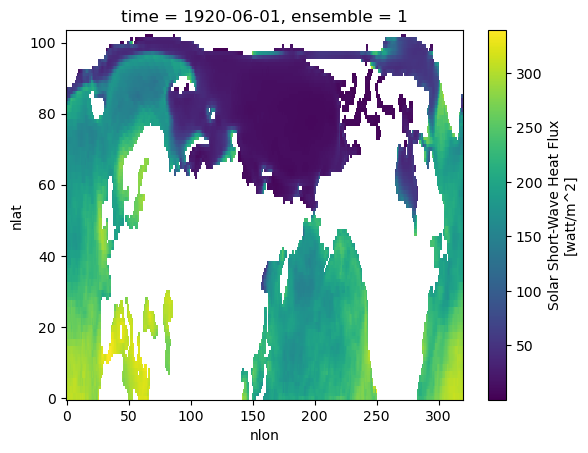

In [23]:
ds_SHF_QSW_nh.SHF_QSW.isel(nlat=slice(384-104,384), time=5, ensemble=1).plot()

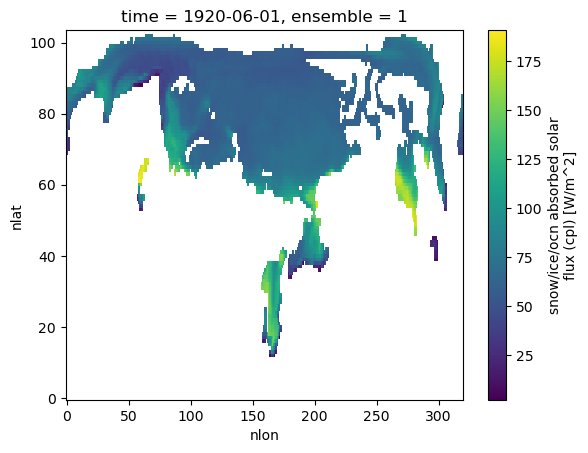

In [24]:
ds_fswabs_nh.fswabs.isel(time=5, ensemble=1).plot()

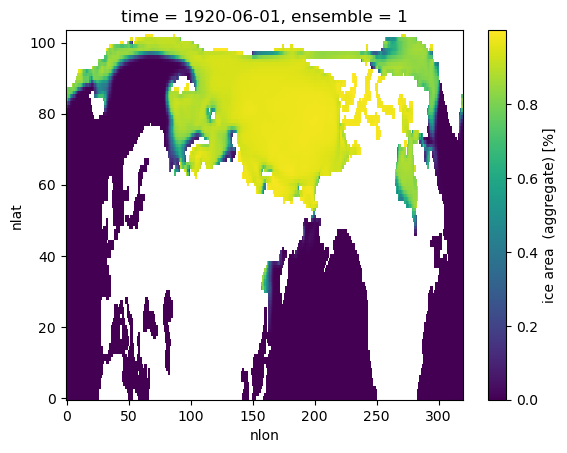

In [25]:
ds_aice_nh.aice.isel(time=5, ensemble=1).plot()

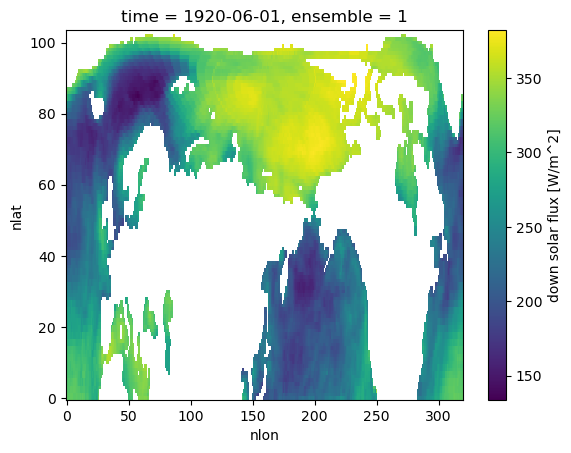

In [26]:
ds_fswdn_nh.fswdn.isel(time=5, ensemble=1).plot()

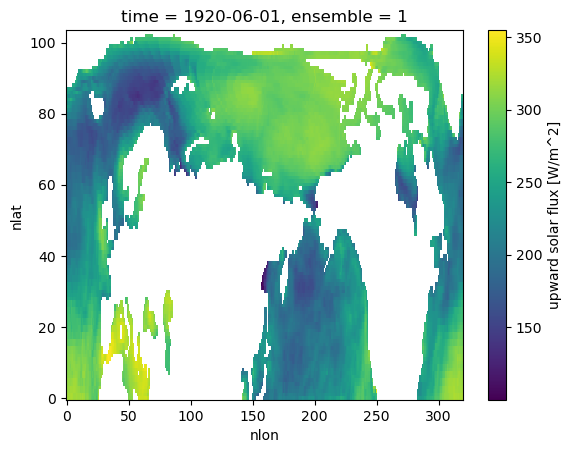

In [27]:
ds_fswup_nh.fswup.isel(time=5, ensemble=1).plot()

In [28]:
ds_sw = xr.merge([ds_fswdn_nh['fswdn'], ds_fswup_nh['fswup'],
                  ds_fswabs_nh['fswabs'], ds_SHF_QSW_nh['SHF_QSW'].isel(nlat=slice(384-104,384)),
                  ds_aice_nh['aice']])
ds_sw

<xarray.Dataset>
Dimensions:   (time: 2172, ensemble: 40, nlat: 104, nlon: 320)
Coordinates:
  * time      (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * ensemble  (ensemble) int64 0 1 2 3 4 5 6 7 8 ... 31 32 33 34 35 36 37 38 40
Dimensions without coordinates: nlat, nlon
Data variables:
    fswdn     (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 104, 320), meta=np.ndarray>
    fswup     (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 104, 320), meta=np.ndarray>
    fswabs    (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 104, 320), meta=np.ndarray>
    SHF_QSW   (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 43, 320), meta=np.ndarray>
    aice      (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 104, 320), meta=np.ndarray>
Attributes:
    units:          W/m^2
    long_name:      down solar flux
    cell_measures:  area: tarea
    comment:        positive downward
    cell_methods:   time: mean
    time_rep:       averaged

In [29]:
# grid.TLONG.isel(nlat=360, nlon=200)

In [30]:
# grid.TLAT.isel(nlat=360, nlon=200)

In [31]:
# ds_sw.isel(ensemble=1, nlat=360, nlon=200).to_netcdf('data_files/shortwave_budget.nc')

In [32]:
# ds_sw.isel(ensemble=1, nlat=382, nlon=300).aice.plot()

In [33]:
grid = grid.isel(nlat=slice(384-104,384))
grid

<xarray.Dataset>
Dimensions:      (nlat: 104, nlon: 320, z_t: 60, z_w: 60, z_w_bot: 60, nreg: 13)
Coordinates:
  * z_t          (z_t) float64 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
  * z_w          (z_w) float64 0.0 1e+03 2e+03 3e+03 ... 4.75e+05 5e+05 5.25e+05
  * z_w_bot      (z_w_bot) float64 1e+03 2e+03 3e+03 ... 5e+05 5.25e+05 5.5e+05
  * nreg         (nreg) int64 0 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: nlat, nlon
Data variables: (12/15)
    TLAT         (nlat, nlon) float64 30.38 30.38 30.38 ... 72.2 72.19 72.19
    TLONG        (nlat, nlon) float64 320.6 321.7 322.8 ... 318.9 319.4 319.8
    ULAT         (nlat, nlon) float64 30.6 30.61 30.61 ... 72.42 72.41 72.41
    ULONG        (nlat, nlon) float64 321.1 322.2 323.3 ... 319.2 319.6 320.0
    DXT          (nlat, nlon) float64 1.07e+07 1.07e+07 ... 1.472e+06 1.473e+06
    DYT          (nlat, nlon) float64 5.032e+06 5.033e+06 ... 5.046e+06
    ...           ...
    UAREA        (nlat, nlon) float64 5.363e+13 5.364e+13 ... 7.639e+12
    KMT          (nlat, nlon) int32 52 53 53 54 56 56 56 56 ... 0 0 0 0 0 0 0 0
    REGION_MASK  (nlat, nlon) int32 6 6 6 6 6 6 6 6 6 6 ... 0 0 0 0 0 0 0 0 0 0
    dz           (z_t) float64 1e+03 1e+03 1e+03 ... 2.499e+04 2.5e+04 2.5e+04
    region_name  (nreg) <U21 'Black Sea' 'Baltic Sea' ... 'Hudson Bay'
    region_val   (nreg) int64 -13 -12 -5 1 2 3 4 6 7 8 9 10 11
Attributes:
    lateral_dims:       [384, 320]
    vertical_dims:      60
    vert_grid_file:     gx1v7_vert_grid
    horiz_grid_fname:   inputdata/ocn/pop/gx1v7/grid/horiz_grid_20010402.ieeer8
    topography_fname:   inputdata/ocn/pop/gx1v7/grid/topography_20161215.ieeei4
    region_mask_fname:  inputdata/ocn/pop/gx1v7/grid/region_mask_20151008.ieeei4
    type:               dipole
    title:              POP_gx1v7 grid

Writing down the equation for change in solar insolation

\begin{equation}
    Q_{\downarrow}^\prime = \overline{Q_{sw}} \bigg(\underbrace{C^\prime (\alpha_w  -  \overline{\alpha_{i}})}_\text{I} - \underbrace{\overline{C}\alpha_{i}^\prime}_\text{II}  - \underbrace{(C^\prime \alpha_{i}^\prime)^\prime}_\text{III}\bigg)+  Q_{sw}^\prime \bigg(\underbrace{ 1- \alpha_w}_\text{IV} +  \underbrace{\overline{C} (\alpha_w - \overline{\alpha_i})}_\text{V}\bigg)  + \underbrace{(Q_{sw}^\prime C^\prime(\alpha_w - \overline{\alpha_i}))^\prime}_\text{VI} - \underbrace{(Q_{sw}^\prime \overline{C}\alpha_{i}^\prime)^\prime}_\text{VII} - \underbrace{(Q_{sw}^\prime C^\prime \alpha_{i}^\prime)^\prime}_\text{VIII}.
\end{equation}


In [34]:
# # writing down the variables that we're gonna use to construct the terms

#shortwave 
sw_avg = ds_sw.fswdn.sel(time=slice('1920-01','1950-12')).groupby('time.month').mean('time')
sw = ds_sw.fswdn
sw_ref = sw.sel(time=slice('1920-01', '1950-12')).groupby('time.month').mean('time')
sw_change = sw.groupby('time.month') - sw_ref

# sea ice albedo
ds_sw['sialb'] = (ds_sw.fswdn-ds_sw.fswabs)/ds_sw.fswdn
alb_i_avg = ds_sw.sialb.sel(time=slice('1920-01','1950-12')).groupby('time.month').mean('time')
alb_i = ds_sw.sialb
alb_i_ref = alb_i.sel(time=slice('1920-01', '1950-12')).groupby('time.month').mean('time')
alb_i_change = alb_i.groupby('time.month') - alb_i_ref

#seawater albedo
alb_w_avg = 0.07

# sea ice concentration\
ds_sw['aice'] = ds_sw['aice'].fillna(0)
aice_avg = ds_sw.aice.sel(time=slice('1920-01','1950-12')).groupby('time.month').mean('time')
aice = ds_sw.aice
aice_ref = aice.sel(time=slice('1920-01', '1950-12')).groupby('time.month').mean('time')
aice_change = aice.groupby('time.month') - aice_ref

# sw_abs
sw_abs = (ds_sw.fswabs*aice).fillna(0)  + (ds_sw.SHF_QSW).where(aice==0).fillna(0) + \
            (ds_sw.SHF_QSW)*(1-aice).where(aice>0).fillna(0)

sw_abs_ref = sw_abs.sel(time=slice('1920-01', '1950-12')).groupby('time.month').mean('time')
sw_abs_change = sw_abs.groupby('time.month') - sw_abs_ref


/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing with an out-of-order index is generating 181 times more chunks
  return self.array[key]


In [35]:
# area = ds_fswabs_nh_ens1_cmip.tarea.where(ds_fswabs_nh_ens1_cmip.tarea>0)
# Area for Holland et al 2015
area = grid.TAREA.where(grid.TLAT>66) # make this NH
# saice = aice.sel(time=slice('1920-01','1950-12')).groupby('time.month')[9].mean(dim=['time','ensemble'],skipna=True)
# area = area.where(saice>0)
area = area.where(ds_sw.fswdn.sel(time='2020-06',ensemble=10).squeeze()>0)
area = area*1e4
area

<xarray.DataArray 'TAREA' (nlat: 104, nlon: 320)>
dask.array<mul, shape=(104, 320), dtype=float64, chunksize=(104, 320), chunktype=numpy.ndarray>
Coordinates:
    time      datetime64[ns] 2020-06-01
    ensemble  int64 10
Dimensions without coordinates: nlat, nlon
Attributes:
    units:        cm^2
    long_name:    area of T cells
    coordinates:  TLONG TLAT

### Absorbed shortwave $Q_{\downarrow}^\prime$

In [36]:
SW_abs = sw_abs

In [37]:
# area and concentration weighted value

SW_abs_num_ice = (SW_abs.where(aice>0.15)*area).sum(('nlat','nlon'), skipna=True)
SW_abs_den_ice = (area).sum(('nlat','nlon'), skipna=True)
SW_abs_ice = SW_abs_num_ice/SW_abs_den_ice

SW_abs_num_ocn = (SW_abs.where(aice<0.15)*area).sum(('nlat','nlon'), skipna=True)
SW_abs_den_ocn = (area).sum(('nlat','nlon'), skipna=True)
SW_abs_ocn = SW_abs_num_ocn/SW_abs_den_ocn

SW_abs_num = (SW_abs*area).sum(('nlat','nlon'), skipna=True)
SW_abs_den = (area).sum(('nlat','nlon'), skipna=True)
SW_abs_sum = SW_abs_num/SW_abs_den

In [38]:
SW_abs_ocn = SW_abs_ocn.load()

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/distributed/client.py:3125: UserWarning: Sending large graph of size 1.01 GiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


In [39]:
SW_abs_ice = SW_abs_ice.load()

In [40]:
SW_abs_sum = SW_abs_sum.load()

In [41]:
ds_sw_abs = xr.merge([SW_abs_sum.to_dataset(name='sw_abs'),
                     SW_abs_ocn.to_dataset(name='sw_abs_ocn'),
                     SW_abs_ice.to_dataset(name='sw_abs_ice')])  
ds_sw_abs

<xarray.Dataset>
Dimensions:     (time: 2172, ensemble: 40)
Coordinates:
  * time        (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * ensemble    (ensemble) int64 0 1 2 3 4 5 6 7 8 ... 32 33 34 35 36 37 38 40
Data variables:
    sw_abs      (ensemble, time) float64 0.06138 1.608 11.38 ... 0.603 0.005468
    sw_abs_ocn  (ensemble, time) float64 0.03611 0.7062 ... 0.6024 0.005468
    sw_abs_ice  (ensemble, time) float64 0.02527 0.9015 ... 0.0005774 3.914e-07

In [42]:
ds_sw_abs.to_netcdf('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/SW_absorbed_LENS1.nc')

CPU times: user 3 µs, sys: 0 ns, total: 3 µs
Wall time: 5.25 µs


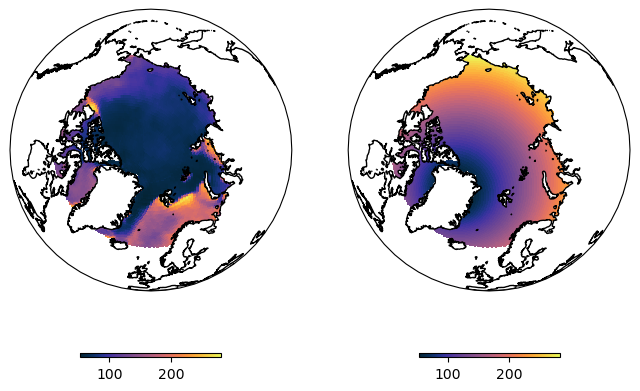

In [43]:
%time

name='NearsidePerspective'
proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# Define the figure and each axis for the 3 rows and 3 columns
fig, ax = plt.subplots(ncols=2, subplot_kw = {'projection': proj}, figsize=(8,8))
ax = ax.flatten()

cf = ax[0].pcolormesh(grid.TLONG, grid.TLAT, (SW_abs).where(area>66).sel(time='2020-06',ensemble=10).squeeze(),
                    cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree())
ax[1].pcolormesh(grid.TLONG, grid.TLAT, area,
                   cmap=cmocean.cm.thermal, transform=ccrs.PlateCarree())
# ax.pcolormesh(grid.TLONG, grid.TLAT, (ds_1.aice).sel(time='1980-03').mean('ensemble').squeeze(), alpha=0.5,cmap=cmocean.cm.ice, vmin=0, vmax=1, transform=ccrs.PlateCarree())
# ax.contour(grid.TLONG, grid.TLAT, ds_1.aice.sel(time='1980-03').mean('ensemble').squeeze() ,  colors='w', levels=[0], transform=ccrs.PlateCarree())

for i in range(2):
    ax[i].coastlines()
    # ax[i].add_feature(land_50m, facecolor='grey')

# Draw the colorbar
    cbar = fig.colorbar(cf, ax=ax[i], shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')
# cbar.set_ticks(np.linspace(0,1,5))
# cbar.ax.set_xlabel('sea ice conc', fontsize=18)
# cbar.ax.xaxis.set_label_position('bottom')
# cbar.ax.tick_params(labelsize=18)  # Set the font size of the ticks
# ax.set_title('September 2020')

# plt.savefig('figs/seaice_conc_threshold_66.png', format='png', bbox_inches='tight', dpi=300)

### IV = $Q_{sw}^\prime ( 1- \alpha_w)$


In [44]:
I_V = sw_change*(1-alb_w_avg)

CPU times: user 5 µs, sys: 1 µs, total: 6 µs
Wall time: 11.2 µs


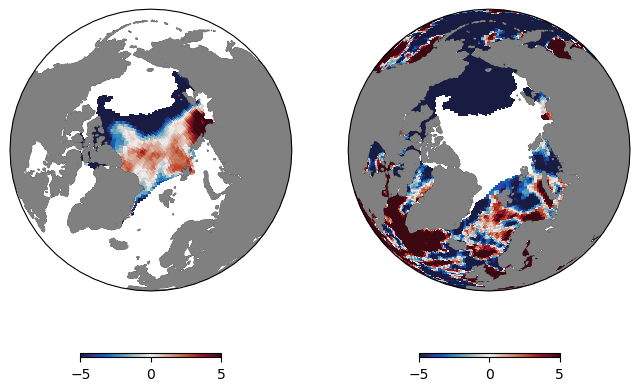

In [45]:
%time

name='NearsidePerspective'
proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# Define the figure and each axis for the 3 rows and 3 columns
fig, ax = plt.subplots(ncols=2, subplot_kw = {'projection': proj}, figsize=(8,8))
ax = ax.flatten()

cf = ax[0].pcolormesh(grid.TLONG, grid.TLAT, (I_V.where(aice>0.15)).sel(time='2020-09',ensemble=10).squeeze(), 
                   vmin=-5, vmax=5, cmap=cmocean.cm.balance, transform=ccrs.PlateCarree())
ax[1].pcolormesh(grid.TLONG, grid.TLAT, (I_V.where(aice<0.15)).sel(time='2020-09',ensemble=10).squeeze(), 
                   vmin=-5, vmax=5, cmap=cmocean.cm.balance, transform=ccrs.PlateCarree())
# ax.pcolormesh(grid.TLONG, grid.TLAT, (ds_1.aice).sel(time='1980-03').mean('ensemble').squeeze(), alpha=0.5,cmap=cmocean.cm.ice, vmin=0, vmax=1, transform=ccrs.PlateCarree())
# ax.contour(grid.TLONG, grid.TLAT, ds_1.aice.sel(time='1980-03').mean('ensemble').squeeze() ,  colors='w', levels=[0], transform=ccrs.PlateCarree())

for i in range(2):
    ax[i].coastlines()
    ax[i].add_feature(land_50m, facecolor='grey')

# Draw the colorbar
    cbar = fig.colorbar(cf, ax=ax[i], shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')
# cbar.set_ticks(np.linspace(0,1,5))
# cbar.ax.set_xlabel('sea ice conc', fontsize=18)
# cbar.ax.xaxis.set_label_position('bottom')
# cbar.ax.tick_params(labelsize=18)  # Set the font size of the ticks
# ax.set_title('September 2020')

# plt.savefig('figs/seaice_conc_threshold_66.png', format='png', bbox_inches='tight', dpi=300)

In [46]:
# area and concentration weighted value
I_V_num_ice = (I_V.where(aice>0.15)*area).sum(('nlat','nlon'), skipna=True)
I_V_den_ice = (area).sum(('nlat','nlon'), skipna=True)
I_V_ice = I_V_num_ice/I_V_den_ice

I_V_num_ocn = (I_V.where(aice<0.15)*area).sum(('nlat','nlon'), skipna=True)
I_V_den_ocn = (area).sum(('nlat','nlon'), skipna=True)
I_V_ocn = I_V_num_ocn/I_V_den_ocn

I_V_num = (I_V*area).sum(('nlat','nlon'), skipna=True)
I_V_den = (area).sum(('nlat','nlon'), skipna=True)
I_V_sum = I_V_num/I_V_den

In [47]:
I_V_sum_ice = I_V_ice.load()

In [48]:
I_V_sum_ocn = I_V_ocn.load()

In [49]:
I_V_sum = I_V_sum.load()

Text(0, 0.5, '$\\mathbf{Q_{sw}^\\prime ( 1- \\alpha_w)}$ [W/m$^2$]')

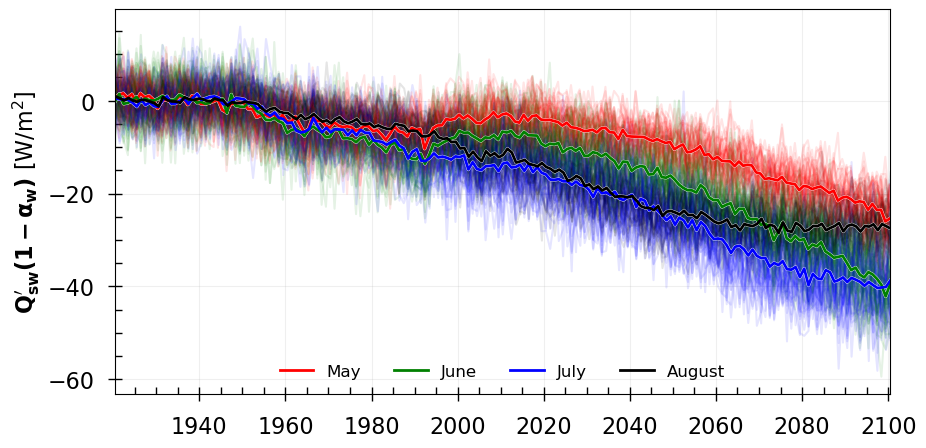

In [50]:
fig, ax  = plt.subplots(figsize=(10,5))

for ensemble in I_V_sum.ensemble:
    ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).sel(ensemble=ensemble), 'r', alpha=0.1)
    ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).sel(ensemble=ensemble), 'g', alpha=0.1)
    ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).sel(ensemble=ensemble), 'b', alpha=0.1)
    ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).sel(ensemble=ensemble), 'k', alpha=0.1)
    
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='w', lw=2.5) 

ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='r', lw=2, label='May')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='g', lw=2,label='June')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='b', lw=2,label='July')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='1850-01', method='nearest'),
            I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))

# ax.set_ylim(-80,80)

ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime ( 1- \alpha_w)}$ [W/m$^2$]', fontsize=16)

# plt.savefig('figs/term_4.png', format='png', bbox_inches='tight', dpi=300)

Text(0, 0.5, '$\\mathbf{Q_{sw}^\\prime ( 1- \\alpha_w)}$ [W/m$^2$]')

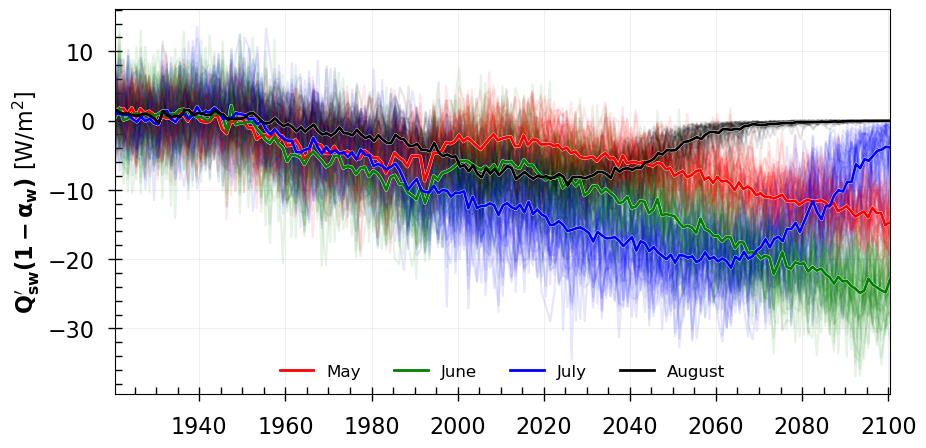

In [51]:
fig, ax  = plt.subplots(figsize=(10,5))

for ensemble in I_V_sum.ensemble:
    ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[5]).sel(ensemble=ensemble), 'r', alpha=0.1)
    ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[6]).sel(ensemble=ensemble), 'g', alpha=0.1)
    ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[7]).sel(ensemble=ensemble), 'b', alpha=0.1)
    ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[8]).sel(ensemble=ensemble), 'k', alpha=0.1)
    
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='w', lw=2.5) 

ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='r', lw=2, label='May')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='g', lw=2,label='June')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='b', lw=2,label='July')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='1850-01', method='nearest'),
            I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))

# ax.set_ylim(-80,80)

ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime ( 1- \alpha_w)}$ [W/m$^2$]', fontsize=16)

# plt.savefig('figs/term_4.png', format='png', bbox_inches='tight', dpi=300)

Text(0, 0.5, '$\\mathbf{Q_{sw}^\\prime ( 1- \\alpha_w)}$ [W/m$^2$]')

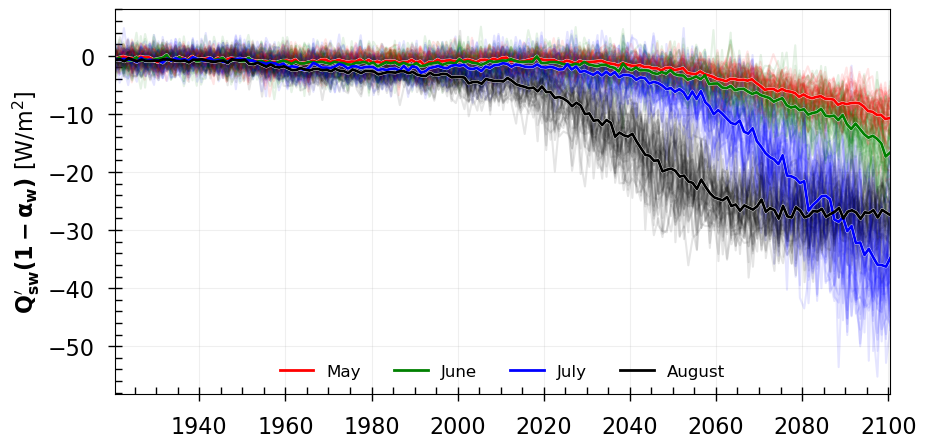

In [52]:
fig, ax  = plt.subplots(figsize=(10,5))

for ensemble in I_V_sum.ensemble:
    ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[5]).sel(ensemble=ensemble), 'r', alpha=0.1)
    ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[6]).sel(ensemble=ensemble), 'g', alpha=0.1)
    ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[7]).sel(ensemble=ensemble), 'b', alpha=0.1)
    ax.plot(I_V_sum_ice.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[8]).sel(ensemble=ensemble), 'k', alpha=0.1)
    
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='w', lw=2.5) 

ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[5]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='r', lw=2, label='May')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='g', lw=2,label='June')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[7]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='b', lw=2,label='July')
ax.plot(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[8]).time, I_V_sum_ocn.isel(time=(I_V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='1850-01', method='nearest'),
            I_V_sum.isel(time=(I_V_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))

# ax.set_ylim(-80,80)

ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime ( 1- \alpha_w)}$ [W/m$^2$]', fontsize=16)

# plt.savefig('figs/term_4.png', format='png', bbox_inches='tight', dpi=300)

### V = $Q_{sw}^\prime\overline{C} (\alpha_w - \overline{\alpha_i}) $

In [53]:
V = sw_change.groupby('time.month')*(aice_avg*(alb_w_avg-alb_i_avg))

In [54]:
# # area and concentration weighted value
# V_num = (V*area).sum(('nlat','nlon'))
# V_den = (area).sum(('nlat','nlon'))
# V_sum = V_num/V_den

In [55]:
# area and concentration weighted value
V_num_ice = (V.where(aice>0.15)*area).sum(('nlat','nlon'), skipna=True)
V_den_ice = (area).sum(('nlat','nlon'), skipna=True)
V_ice = V_num_ice/V_den_ice

V_num_ocn = (V.where(aice<0.15)*area).sum(('nlat','nlon'), skipna=True)
V_den_ocn = (area).sum(('nlat','nlon'), skipna=True)
V_ocn = V_num_ocn/V_den_ocn

V_num = (V*area).sum(('nlat','nlon'), skipna=True)
V_den = (area).sum(('nlat','nlon'), skipna=True)
V_sum = V_num/V_den

In [56]:
V_sum_ice = V_ice.load()

In [57]:
V_sum_ocn = V_ocn.load()

In [58]:
V_sum = V_sum.load()

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.01 µs


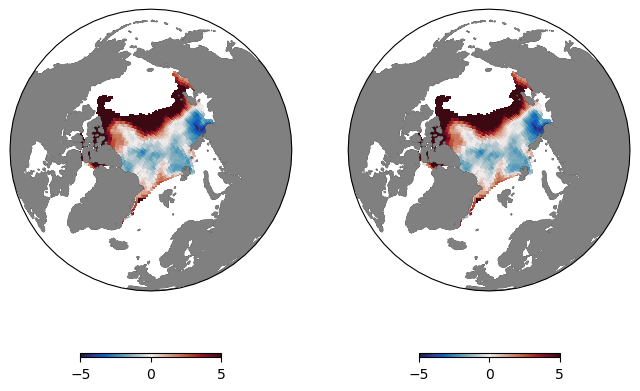

In [59]:
%time

name='NearsidePerspective'
proj=ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)


# Define the figure and each axis for the 3 rows and 3 columns
fig, ax = plt.subplots(ncols=2, subplot_kw = {'projection': proj}, figsize=(8,8))
ax = ax.flatten()

cf = ax[0].pcolormesh(grid.TLONG, grid.TLAT, (V.where(aice>0.15)).sel(time='2020-09',ensemble=10).squeeze(), 
                   vmin=-5, vmax=5, cmap=cmocean.cm.balance, transform=ccrs.PlateCarree())
ax[1].pcolormesh(grid.TLONG, grid.TLAT, (V.where(aice>0.15)).sel(time='2020-09',ensemble=10).squeeze(), 
                   vmin=-5, vmax=5, cmap=cmocean.cm.balance, transform=ccrs.PlateCarree())
# ax.pcolormesh(grid.TLONG, grid.TLAT, (ds_1.aice).sel(time='1980-03').mean('ensemble').squeeze(), alpha=0.5,cmap=cmocean.cm.ice, vmin=0, vmax=1, transform=ccrs.PlateCarree())
# ax.contour(grid.TLONG, grid.TLAT, ds_1.aice.sel(time='1980-03').mean('ensemble').squeeze() ,  colors='w', levels=[0], transform=ccrs.PlateCarree())

for i in range(2):
    ax[i].coastlines()
    ax[i].add_feature(land_50m, facecolor='grey')

# Draw the colorbar
    cbar = fig.colorbar(cf, ax=ax[i], shrink = 0.5, aspect = 30 , pad = 0.1 , orientation='horizontal')
# cbar.set_ticks(np.linspace(0,1,5))
# cbar.ax.set_xlabel('sea ice conc', fontsize=18)
# cbar.ax.xaxis.set_label_position('bottom')
# cbar.ax.tick_params(labelsize=18)  # Set the font size of the ticks
# ax.set_title('September 2020')

# plt.savefig('figs/seaice_conc_threshold_66.png', format='png', bbox_inches='tight', dpi=300)

In [60]:
# V_sum = V_sum.load()

Text(0, 0.5, '$\\mathbf{Q_{sw}^\\prime\\overline{C} (\\alpha_w - \\overline{\\alpha_i})} $ [W/m$^2$]')

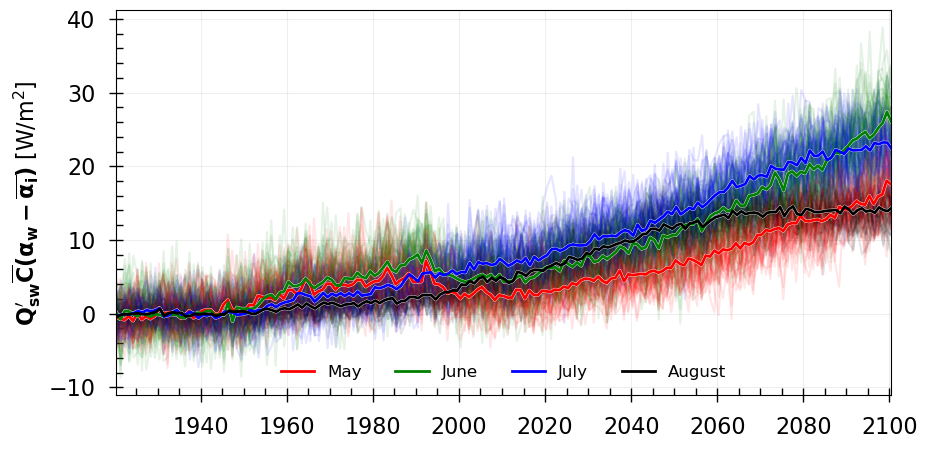

In [61]:
fig, ax  = plt.subplots(figsize=(10,5))

for ensemble in V_sum.ensemble:
    ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).sel(ensemble=ensemble), 'r', alpha=0.1)
    ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).sel(ensemble=ensemble), 'g', alpha=0.1)
    ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).sel(ensemble=ensemble), 'b', alpha=0.1)
    ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).sel(ensemble=ensemble), 'k', alpha=0.1)
    
ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='w', lw=2.5) 
ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='w', lw=2.5) 

ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[5]).mean(dim=['ensemble']), c='r', lw=2, label='May')
ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).mean(dim=['ensemble']), c='g', lw=2,label='June')
ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[7]).mean(dim=['ensemble']), c='b', lw=2,label='July')
ax.plot(V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).time, V_sum.isel(time=(V_sum.groupby('time.month').groups)[8]).mean(dim=['ensemble']), c='k', lw=2,label='August')


ax.tick_params(which='both',
           labelcolor='k', 
           labelsize=16, 
           direction='inout',
           width=1,
           length=10,
           pad=10)

ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='minor', direction='in', length=5, width=1, color='k')
ax.grid(alpha=0.2)
ax.legend(loc='lower center', ncol=4, frameon=False, fontsize=12)

ax.set_xlim(V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time.sel(time='1850-01', method='nearest'),
            V_sum.isel(time=(V_sum.groupby('time.month').groups)[6]).time.sel(time='2100-12', method='nearest'))



ax.set_ylabel(r'$\mathbf{Q_{sw}^\prime\overline{C} (\alpha_w - \overline{\alpha_i})} $ [W/m$^2$]', fontsize=16)

# plt.savefig('figs/term_5.png', format='png', bbox_inches='tight', dpi=300)

### Saving the terms

In [62]:
q_prime_ice = I_V_sum_ice + V_sum_ice
q_prime_ocn = I_V_sum_ocn + V_sum_ocn

In [63]:
q_prime_ocn.to_dataset(name=('q_prime_ocn'))

<xarray.Dataset>
Dimensions:      (time: 2172, ensemble: 40)
Coordinates:
  * time         (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * ensemble     (ensemble) int64 0 1 2 3 4 5 6 7 8 ... 32 33 34 35 36 37 38 40
    month        (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    q_prime_ocn  (ensemble, time) float64 -0.002999 0.02167 ... -0.0001996

In [64]:
ds_q_prime = xr.merge([q_prime_ice.to_dataset(name=('q_prime_ice')), q_prime_ocn.to_dataset(name=('q_prime_ocn'))])
ds_q_prime

<xarray.Dataset>
Dimensions:      (time: 2172, ensemble: 40)
Coordinates:
  * time         (time) datetime64[ns] 1920-01-01 1920-02-01 ... 2100-12-01
  * ensemble     (ensemble) int64 0 1 2 3 4 5 6 7 8 ... 32 33 34 35 36 37 38 40
    month        (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    q_prime_ice  (ensemble, time) float64 0.0003923 0.07042 ... -6.145e-09
    q_prime_ocn  (ensemble, time) float64 -0.002999 0.02167 ... -0.0001996

In [65]:
ds_q_prime.to_netcdf('~/CESM2-LENS/Arctic_sea_ice_albedo/data_files/q_prime_decomp_LENS1.nc')

In [66]:
# remove temp dask worker files
!rm -f dask*
client.close()